In [ ]:
!pip install -q transformers datasets accelerate
!pip install -q scikit-learn xgboost shap seaborn matplotlib
print("✅ Done")

✅ Done


In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve,
                             accuracy_score, f1_score)
from xgboost import XGBClassifier
import shap

print("✅ Imports done")

✅ Imports done


In [ ]:
from google.colab import files
uploaded = files.upload()
# Upload logon.csv and device.csv

Saving device.csv to device.csv
Saving logon.csv to logon.csv


In [ ]:
logon_df  = pd.read_csv('/content/logon.csv')
device_df = pd.read_csv('/content/device.csv')
print("logon_df  :", logon_df.shape)
print("device_df :", device_df.shape)

logon_df  : (849579, 5)
device_df : (65668, 5)


In [ ]:
logon_df['date']       = pd.to_datetime(logon_df['date'], format='mixed', dayfirst=True)
logon_df['hour']       = logon_df['date'].dt.hour
logon_df['dayofweek']  = logon_df['date'].dt.dayofweek
logon_df['is_weekend'] = logon_df['dayofweek'].isin([5,6]).astype(int)
logon_df['is_night']   = logon_df['hour'].apply(lambda x: 1 if x < 6 or x >= 22 else 0)
logon_df['user_short'] = logon_df['user'].str.replace('DTAA/', '', regex=False)
logon_df.drop_duplicates(inplace=True)

device_df['date']       = pd.to_datetime(device_df['date'], format='mixed', dayfirst=True)
device_df['user_short'] = device_df['user'].str.replace('DTAA/', '', regex=False)
device_df.drop_duplicates(inplace=True)

print("✅ Preprocessing done")

✅ Preprocessing done


In [ ]:
logon_stats = logon_df.groupby('user_short').agg(
    total_logons   = ('activity', lambda x: (x=='Logon').sum()),
    total_logoffs  = ('activity', lambda x: (x=='Logoff').sum()),
    night_logons   = ('is_night', 'sum'),
    weekend_logons = ('is_weekend', 'sum'),
    unique_pcs     = ('pc', 'nunique')
).reset_index()

device_stats = device_df.groupby('user_short').agg(
    usb_connects    = ('activity', lambda x: (x=='Connect').sum()),
    usb_disconnects = ('activity', lambda x: (x=='Disconnect').sum())
).reset_index()
device_stats['total_usb'] = device_stats['usb_connects'] + device_stats['usb_disconnects']

user_features = logon_stats.merge(device_stats, on='user_short', how='left').fillna(0)
print("✅ user_features:", user_features.shape)

✅ user_features: (1000, 9)


In [ ]:
user_features['label'] = 0
user_features.loc[user_features['night_logons'] >= 100, 'label'] = 1
user_features.loc[user_features['usb_connects']  >= 150, 'label'] = 1

print("Label Distribution:")
print(user_features['label'].value_counts())
print("Threat %:", round(user_features['label'].mean()*100, 2), "%")

Label Distribution:
label
0    883
1    117
Name: count, dtype: int64
Threat %: 11.7 %


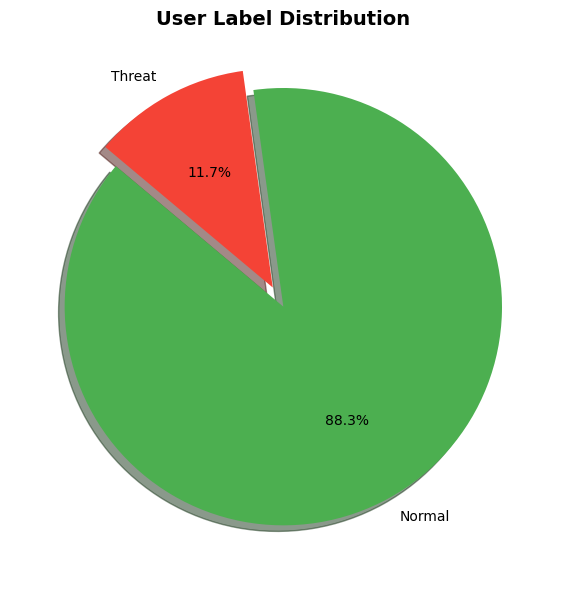

✅ Pie chart done


In [ ]:
label_counts = user_features['label'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(label_counts,
        labels=['Normal','Threat'],
        colors=['#4CAF50','#F44336'],
        explode=(0, 0.1),
        autopct='%1.1f%%',
        startangle=140,
        shadow=True)
plt.title('User Label Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/pie_chart.png', dpi=150)
plt.show()
print("✅ Pie chart done")

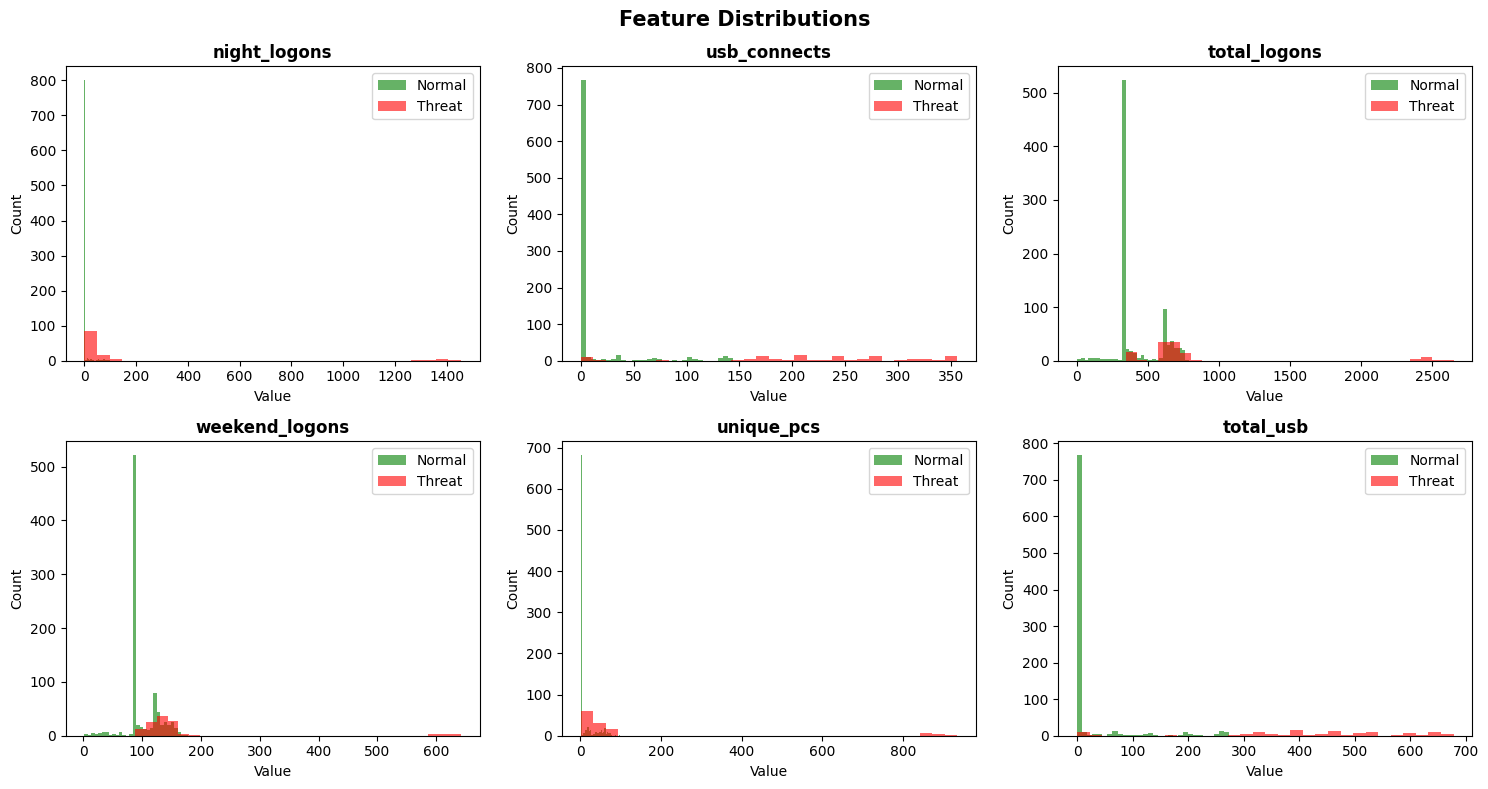

✅ Histograms done


In [ ]:
features_to_plot = ['night_logons','usb_connects','total_logons',
                    'weekend_logons','unique_pcs','total_usb']

fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    axes[i].hist(user_features[user_features['label']==0][feat],
                 bins=30, alpha=0.6, color='green', label='Normal')
    axes[i].hist(user_features[user_features['label']==1][feat],
                 bins=30, alpha=0.6, color='red', label='Threat')
    axes[i].set_title(feat, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/histograms.png', dpi=150)
plt.show()
print("✅ Histograms done")

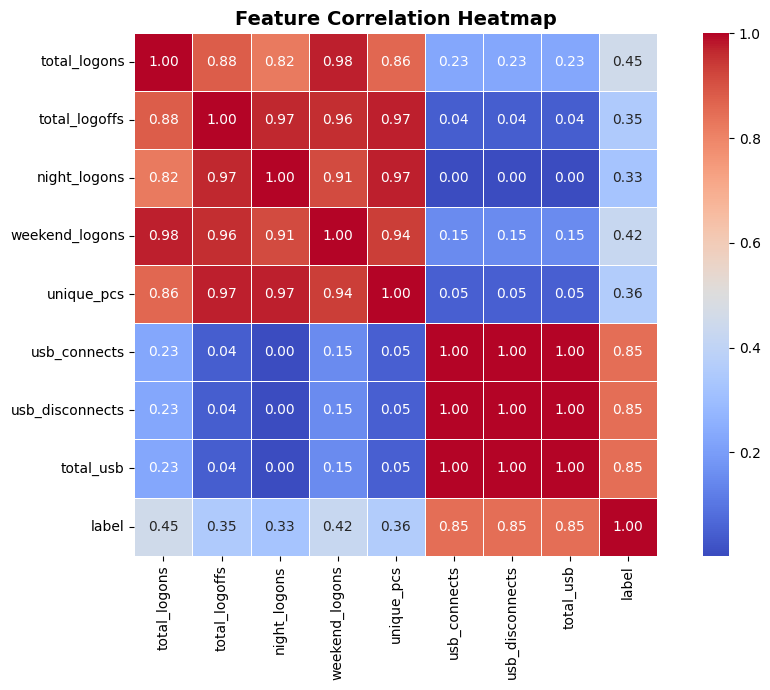

✅ Heatmap done


In [ ]:
feature_cols = ['total_logons','total_logoffs','night_logons',
                'weekend_logons','unique_pcs','usb_connects',
                'usb_disconnects','total_usb','label']

plt.figure(figsize=(10,7))
sns.heatmap(user_features[feature_cols].corr(),
            annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/heatmap.png', dpi=150)
plt.show()
print("✅ Heatmap done")

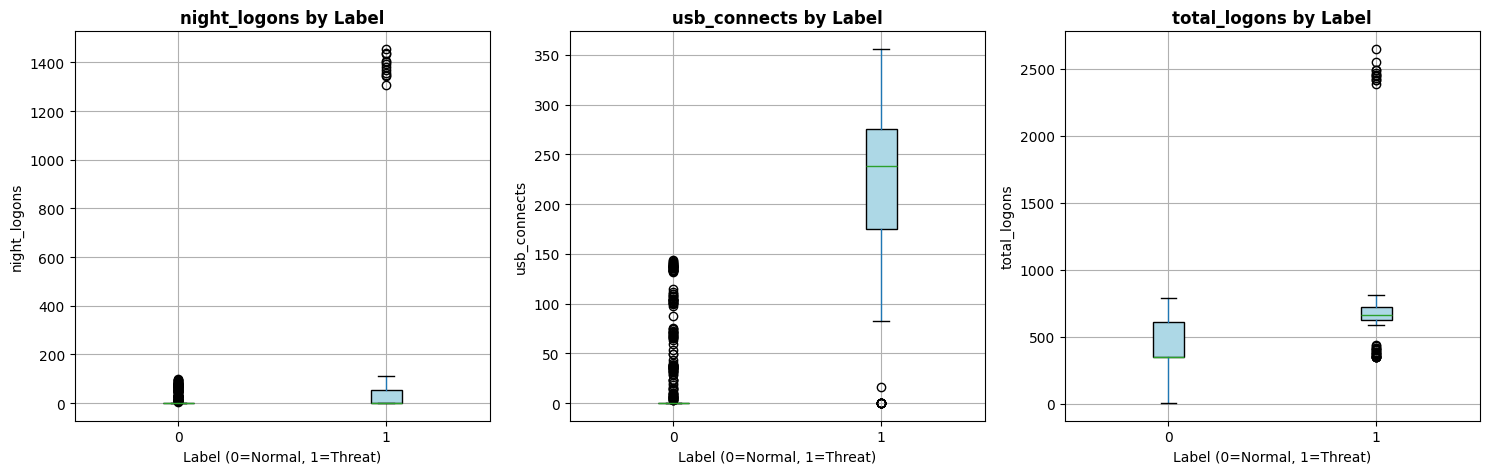

✅ Boxplots done


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, feat in zip(axes, ['night_logons','usb_connects','total_logons']):
    user_features.boxplot(column=feat, by='label', ax=ax,
                          patch_artist=True,
                          boxprops=dict(facecolor='lightblue'))
    ax.set_title(f'{feat} by Label', fontsize=12, fontweight='bold')
    ax.set_xlabel('Label (0=Normal, 1=Threat)')
    ax.set_ylabel(feat)

plt.suptitle('')
plt.tight_layout()
plt.savefig('/content/boxplots.png', dpi=150)
plt.show()
print("✅ Boxplots done")

In [ ]:
def build_sequence(user):
    user_logs = logon_df[logon_df['user_short']==user].head(50)
    events = []
    for _, row in user_logs.iterrows():
        action = 'Logon' if row['activity']=='Logon' else 'Logoff'
        events.append(f"{action} at hour {row['hour']} on {row['pc']}")
    return " | ".join(events)

user_features['text_sequence'] = user_features['user_short'].apply(build_sequence)
print("✅ Text sequences built")

✅ Text sequences built


In [ ]:
train_df, temp_df = train_test_split(user_features, test_size=0.30,
                                      stratify=user_features['label'], random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.50,
                                      stratify=temp_df['label'], random_state=42)

test_df = test_df.reset_index(drop=True)
print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))

Train: 700 | Val: 150 | Test: 150


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_id  = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)
model.eval()
print("✅ TinyLlama loaded")

def predict_user(text):
    short_text = text[:100]
    prompt = f"Classify user behavior as THREAT or NORMAL.\nBehavior: {short_text}\nAnswer:"
    inputs = tokenizer(prompt, return_tensors="pt",
                       truncation=True, max_length=128).to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=3,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
    result  = decoded.split("Answer:")[-1].strip()
    return 1 if "THREAT" in result.upper() else 0

# Predict on 20 samples only
test_sample = test_df.head(20).copy()
test_sample['llm_predicted'] = test_sample['text_sequence'].apply(predict_user)

# Fill full test_df
test_df['llm_predicted'] = 0
test_df.loc[:19, 'llm_predicted'] = test_sample['llm_predicted'].values

print("✅ LLM predictions done")
print(test_df['llm_predicted'].value_counts())

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

[transformers] Both `max_new_tokens` (=3) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✅ TinyLlama loaded


[transformers] Both `max_new_tokens` (=3) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=3) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=3) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=3) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

✅ LLM predictions done
llm_predicted
0    130
1     20
Name: count, dtype: int64


In [ ]:
feature_cols = ['total_logons','total_logoffs','night_logons',
                'weekend_logons','unique_pcs','usb_connects',
                'usb_disconnects','total_usb']

X_train = train_df[feature_cols]
y_train = train_df['label']
X_test  = test_df[feature_cols]
y_test  = test_df['label']

# XGBoost
xgb = XGBClassifier(n_estimators=100, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

# Isolation Forest
iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(X_train)
iso_preds = [1 if x==-1 else 0 for x in iso.predict(X_test)]

print("=== XGBoost ===")
print(classification_report(y_test, xgb_preds))
print("=== Random Forest ===")
print(classification_report(y_test, rf_preds))
print("=== Isolation Forest ===")
print(classification_report(y_test, iso_preds))
print("✅ Baselines done")

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       133
           1       1.00      0.94      0.97        17

    accuracy                           0.99       150
   macro avg       1.00      0.97      0.98       150
weighted avg       0.99      0.99      0.99       150

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       133
           1       1.00      0.94      0.97        17

    accuracy                           0.99       150
   macro avg       1.00      0.97      0.98       150
weighted avg       0.99      0.99      0.99       150

=== Isolation Forest ===
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       133
           1       0.60      0.71      0.65        17

    accuracy                           0.91       150
   macro avg       0.78      0.82      0.80       150
weighted av

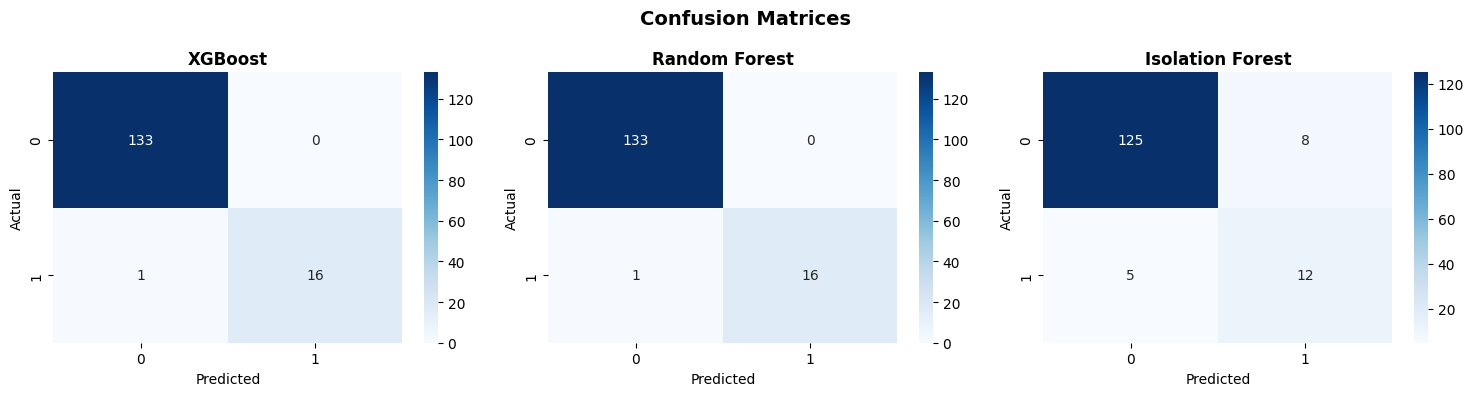

✅ Confusion matrices done


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, preds, title in zip(
    axes,
    [xgb_preds, rf_preds, iso_preds],
    ['XGBoost','Random Forest','Isolation Forest']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{title}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrices done")

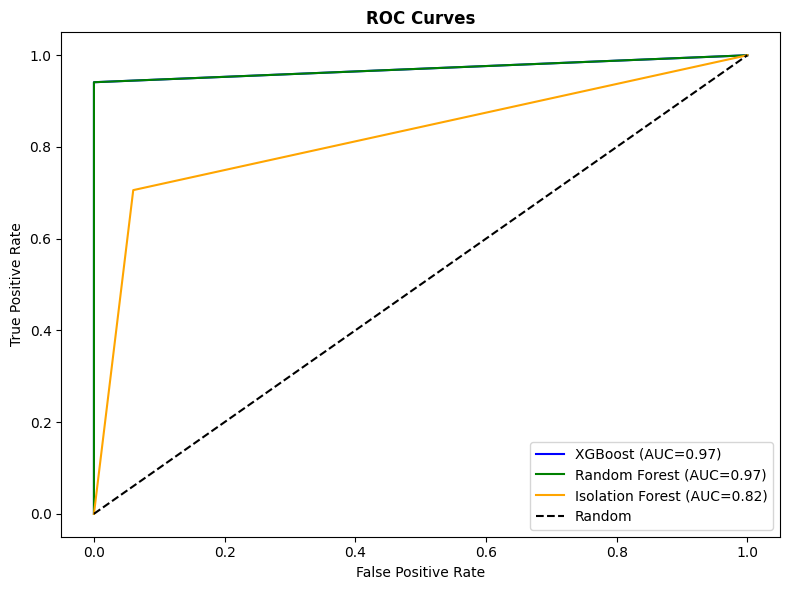

✅ ROC curves done


In [ ]:
plt.figure(figsize=(8,6))

for preds, name, color in zip(
    [xgb_preds, rf_preds, iso_preds],
    ['XGBoost','Random Forest','Isolation Forest'],
    ['blue','green','orange']):
    fpr, tpr, _ = roc_curve(y_test, preds)
    auc = roc_auc_score(y_test, preds)
    plt.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc:.2f})')

plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('/content/roc_curve.png', dpi=150)
plt.show()
print("✅ ROC curves done")

Running SHAP...


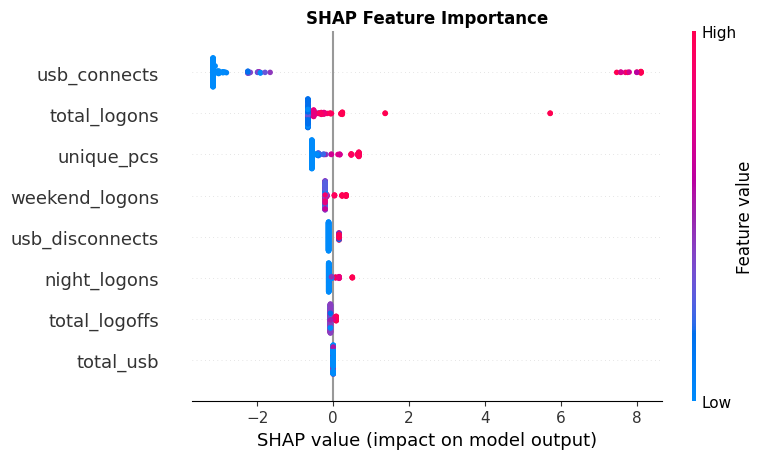

✅ SHAP done


In [ ]:
print("Running SHAP...")
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test,
                  feature_names=feature_cols,
                  show=False)
plt.title('SHAP Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/shap_plot.png', dpi=150)
plt.show()
print("✅ SHAP done")

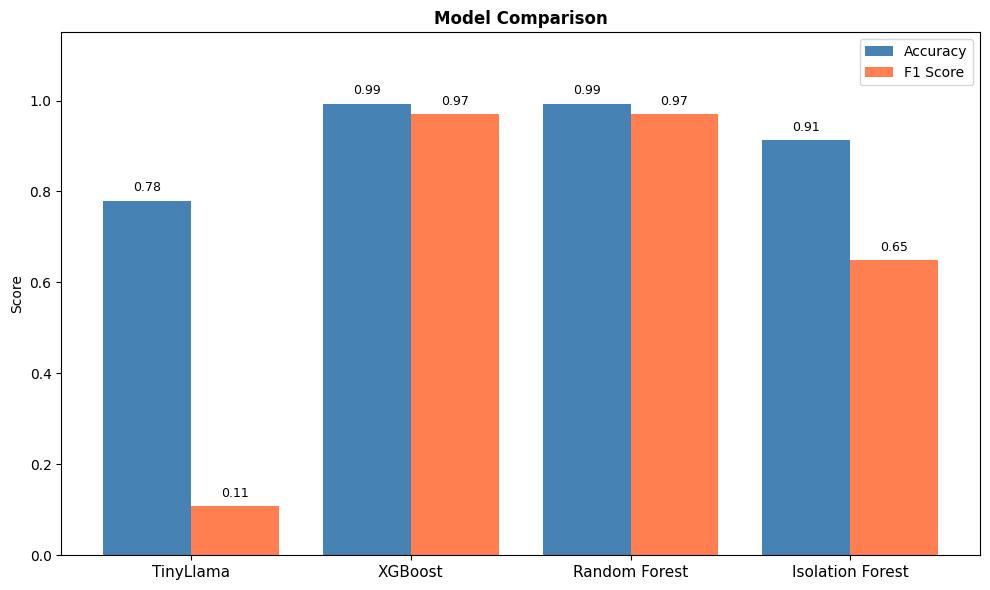


🎉 ALL DONE!
Saved files:
  /content/pie_chart.png
  /content/histograms.png
  /content/heatmap.png
  /content/boxplots.png
  /content/confusion_matrix.png
  /content/roc_curve.png
  /content/shap_plot.png
  /content/model_comparison.png


In [ ]:
models = ['TinyLlama','XGBoost','Random Forest','Isolation Forest']

acc = [
    accuracy_score(y_test, test_df['llm_predicted']),
    accuracy_score(y_test, xgb_preds),
    accuracy_score(y_test, rf_preds),
    accuracy_score(y_test, iso_preds)
]
f1 = [
    f1_score(y_test, test_df['llm_predicted'], zero_division=0),
    f1_score(y_test, xgb_preds, zero_division=0),
    f1_score(y_test, rf_preds, zero_division=0),
    f1_score(y_test, iso_preds, zero_division=0)
]

x   = np.arange(len(models))
fig, ax = plt.subplots(figsize=(10,6))
b1 = ax.bar(x - 0.2, acc, 0.4, label='Accuracy', color='steelblue')
b2 = ax.bar(x + 0.2, f1,  0.4, label='F1 Score',  color='coral')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Model Comparison', fontweight='bold')
ax.legend()

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'{bar.get_height():.2f}',
            ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/model_comparison.png', dpi=150)
plt.show()

print("\n🎉 ALL DONE!")
print("Saved files:")
print("  /content/pie_chart.png")
print("  /content/histograms.png")
print("  /content/heatmap.png")
print("  /content/boxplots.png")
print("  /content/confusion_matrix.png")
print("  /content/roc_curve.png")
print("  /content/shap_plot.png")
print("  /content/model_comparison.png")

In [ ]:


# Get label counts per split
total_users  = len(user_features)
total_threat = user_features['label'].sum()
total_normal = total_users - total_threat

train_threat = train_df['label'].sum()
train_normal = len(train_df) - train_threat

val_threat   = val_df['label'].sum()
val_normal   = len(val_df) - val_threat

test_threat  = test_df['label'].sum()
test_normal  = len(test_df) - test_threat

print("Split            | Total | Normal | Threat")
print("-" * 45)
print(f"Training  (70%)  |  {len(train_df)}  |  {train_normal}   |  {train_threat}")
print(f"Validation(15%)  |  {len(val_df)}   |  {val_normal}    |  {val_threat}")
print(f"Test      (15%)  |  {len(test_df)}   |  {test_normal}    |  {test_threat}")
print("-" * 45)
print(f"Total            | {total_users}  |  {total_normal}   |  {total_threat}")

Split            | Total | Normal | Threat
---------------------------------------------
Training  (70%)  |  700  |  618   |  82
Validation(15%)  |  150   |  132    |  18
Test      (15%)  |  150   |  133    |  17
---------------------------------------------
Total            | 1000  |  883   |  117


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# LLM results
llm_acc  = accuracy_score(y_test, test_df['llm_predicted'])
llm_prec = precision_score(y_test, test_df['llm_predicted'], zero_division=0)
llm_rec  = recall_score(y_test, test_df['llm_predicted'], zero_division=0)
llm_f1   = f1_score(y_test, test_df['llm_predicted'], zero_division=0)
llm_auc  = roc_auc_score(y_test, test_df['llm_predicted'])

# XGBoost results
xgb_acc  = accuracy_score(y_test, xgb_preds)
xgb_prec = precision_score(y_test, xgb_preds, zero_division=0)
xgb_rec  = recall_score(y_test, xgb_preds, zero_division=0)
xgb_f1   = f1_score(y_test, xgb_preds, zero_division=0)
xgb_auc  = roc_auc_score(y_test, xgb_preds)

# Random Forest results
rf_acc  = accuracy_score(y_test, rf_preds)
rf_prec = precision_score(y_test, rf_preds, zero_division=0)
rf_rec  = recall_score(y_test, rf_preds, zero_division=0)
rf_f1   = f1_score(y_test, rf_preds, zero_division=0)
rf_auc  = roc_auc_score(y_test, rf_preds)

# Isolation Forest results
iso_acc  = accuracy_score(y_test, iso_preds)
iso_prec = precision_score(y_test, iso_preds, zero_division=0)
iso_rec  = recall_score(y_test, iso_preds, zero_division=0)
iso_f1   = f1_score(y_test, iso_preds, zero_division=0)
iso_auc  = roc_auc_score(y_test, iso_preds)

print("Model              | Acc   | Prec  | Recall | F1    | AUC")
print("-" * 65)
print(f"TinyLlama          | {llm_acc:.3f} | {llm_prec:.3f} | {llm_rec:.3f}  | {llm_f1:.3f} | {llm_auc:.3f}")
print(f"XGBoost            | {xgb_acc:.3f} | {xgb_prec:.3f} | {xgb_rec:.3f}  | {xgb_f1:.3f} | {xgb_auc:.3f}")
print(f"Random Forest      | {rf_acc:.3f} | {rf_prec:.3f} | {rf_rec:.3f}  | {rf_f1:.3f} | {rf_auc:.3f}")
print(f"Isolation Forest   | {iso_acc:.3f} | {iso_prec:.3f} | {iso_rec:.3f}  | {iso_f1:.3f} | {iso_auc:.3f}")

Model              | Acc   | Prec  | Recall | F1    | AUC
-----------------------------------------------------------------
TinyLlama          | 0.780 | 0.100 | 0.118  | 0.108 | 0.491
XGBoost            | 0.993 | 1.000 | 0.941  | 0.970 | 0.971
Random Forest      | 0.993 | 1.000 | 0.941  | 0.970 | 0.971
Isolation Forest   | 0.913 | 0.600 | 0.706  | 0.649 | 0.823


In [ ]:
# Pick one threat user from test set
threat_users = test_df[test_df['label'] == 1].reset_index(drop=True)
sample_user  = threat_users.iloc[0]
user_id      = sample_user['user_short']
user_data    = user_features[user_features['user_short'] == user_id].iloc[0]

print("User ID         :", user_id)
print("Total Logons    :", int(user_data['total_logons']))
print("Total Logoffs   :", int(user_data['total_logoffs']))
print("Night Logons    :", int(user_data['night_logons']))
print("Weekend Logons  :", int(user_data['weekend_logons']))
print("Unique PCs      :", int(user_data['unique_pcs']))
print("USB Connects    :", int(user_data['usb_connects']))
print("USB Disconnects :", int(user_data['usb_disconnects']))
print("Total USB       :", int(user_data['total_usb']))
print("True Label      :", "THREAT" if sample_user['label']==1 else "NORMAL")
print("LLM Prediction  :", "THREAT" if sample_user['llm_predicted']==1 else "NORMAL")

User ID         : PIP0746
Total Logons    : 651
Total Logoffs   : 368
Night Logons    : 0
Weekend Logons  : 130
Unique PCs      : 21
USB Connects    : 274
USB Disconnects : 243
Total USB       : 517
True Label      : THREAT
LLM Prediction  : THREAT
